In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1774461462.316960 2890392 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

home = os.path.expanduser("~")
dataset_path = os.path.join(home, "hybrid_tumor_project", "extracted_data", "Figshare dataset")

IMG_SIZE = 224

images = []
labels = []

for label, folder in enumerate(sorted(os.listdir(dataset_path))):
    folder_path = os.path.join(dataset_path, folder)

    for file in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # IMPORTANT
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = preprocess_input(img)

            images.append(img)
            labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("Dataset shape:", X.shape)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 930/930 [00:01<00:00, 486.70it/s]


Dataset shape: (3064, 224, 224, 3)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7160385626643295), 1: np.float64(1.4434628975265018), 2: np.float64(1.0981182795698925)}


In [6]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_gen = datagen.flow(X_train, y_train, batch_size=16)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [8]:
base_model = MobileNetV3Small(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

E0000 00:00:1774461478.193801 2890392 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1774461478.193888 2890392 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1774461478.193903 2890392 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1774461478.193911 2890392 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1774461478.193930 2890392 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: srmap
I0000 00:00:1774461478.193935 2890392 cuda_diagnostics.cc:183] hostname: srmap
I0000 00:00:1774461478.194220 2890392 cuda_diagnostics.cc:190] libcuda reported version is: 555.42.2
I0000 00:00:1774461478.194245 2890392 cuda_diagnostics.cc:194] kernel reported ve

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 1,013,363 (3.87 MB)

 Trainable params: 662,435 (2.53 MB)

 Non-trainable params: 350,928 (1.34 MB)

In [9]:
history = model.fit(
    train_gen,
    validation_data=(X_test, y_test),
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20


I0000 00:00:1774461479.720677 2890392 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 242ms/step - accuracy: 0.5916 - loss: 0.9315 - val_accuracy: 0.5873 - val_loss: 0.8104 - learning_rate: 5.0000e-05
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 236ms/step - accuracy: 0.7389 - loss: 0.6239 - val_accuracy: 0.6591 - val_loss: 0.6684 - learning_rate: 5.0000e-05
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 39s 256ms/step - accuracy: 0.8058 - loss: 0.4802 - val_accuracy: 0.7488 - val_loss: 0.5301 - learning_rate: 5.0000e-05
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 227ms/step - accuracy: 0.8401 - loss: 0.4154 - val_accuracy: 0.7977 - val_loss: 0.4672 - learning_rate: 5.0000e-05
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.8454 - loss: 0.3862 - val_accuracy: 0.7830 - val_loss: 0.4643 - learning_rate: 5.0000e-05
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 30s 195ms/step - accuracy: 0.8617 - loss: 0.3582 - val_accuracy: 0.8564 - val_loss: 0.3431 - learning_rate: 5.0000e-05
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - 

In [10]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step
Accuracy: 0.9249592169657422
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       285
           1       0.86      0.83      0.85       142
           2       0.92      0.97      0.95       186

    accuracy                           0.92       613
   macro avg       0.91      0.91      0.91       613
weighted avg       0.92      0.92      0.92       613



In [11]:
classes = sorted(os.listdir(dataset_path))
classes = [c.replace("_tumor","") for c in classes]

print(classes)

['Glioma', 'Meningioma', 'Pituitary']


In [12]:
img_path = os.path.join(home,"hybrid_tumor_project", "866.jpg") 

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

# IMPORTANT: use MobileNet preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
img = preprocess_input(img)

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
pred_class = np.argmax(prediction)

print("Prediction Probabilities:", prediction)
print("Predicted Class:", classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction Probabilities: [[0.75145626 0.24226296 0.00628073]]
Predicted Class: Glioma


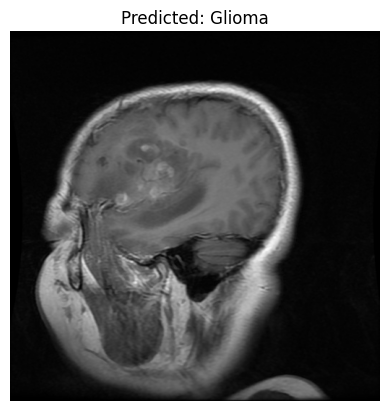

In [13]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {classes[pred_class]}")
plt.axis("off")
plt.show()

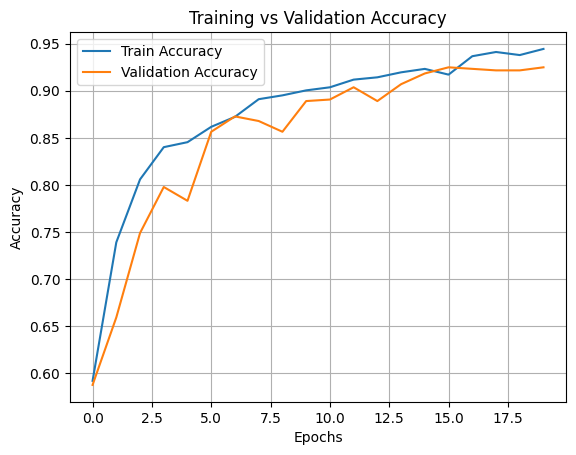

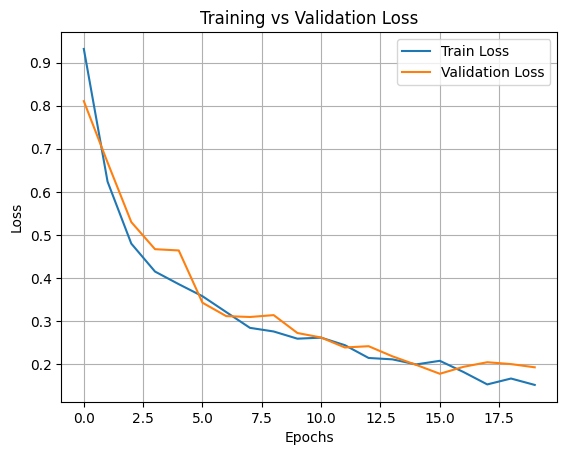

In [14]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step


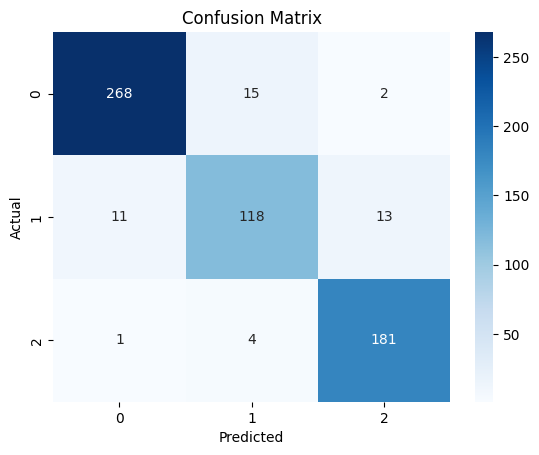

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [19]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [21]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

heatmap = get_gradcam_heatmap(model, img_array, "conv_1")

/home/dgxuser45/.local/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


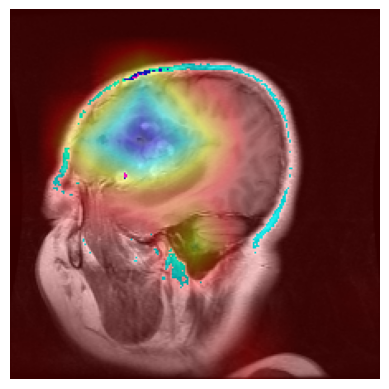

In [22]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")
plt.show()